# Quickstart: your first h5i-db market database

h5i-db is an embedded, versioned time-series database for quant workloads.
There is no server to run. A database is a directory on disk, like SQLite or
DuckDB.

Two things separate it from a generic embedded store. Every write is an atomic
commit that produces an immutable, still-queryable version. And the SQL layer
(Apache DataFusion) ships the time-series operators a desk actually needs:
`time_bucket`, `vwap`, `ewma`, ASOF joins, gapfill.

In five minutes we:

1. look at the tick data we are going to load,
2. create a database and ingest it,
3. compute minute bars with VWAP in one query,
4. read the table as it was before the last load.

In [1]:
import h5i_db
import pyarrow as pa
from h5i_db import col, count_star, time_bucket, vwap

import cookbook_utils as cu

print("h5i-db version:", h5i_db.__version__)

h5i-db version: 0.1.0


## 1. The data

Recipes in this cookbook get their market data from `cookbook_utils`, a set of
synthetic generators that are deterministic given a seed. `cu.make_trades`
returns a tick tape: one row per trade, three symbols, three NYSE sessions.
Arrival times are U-shaped across the session and prices bounce between bid
and ask, so the tape behaves like the real thing.

| column | type | meaning |
| --- | --- | --- |
| `ts` | `timestamp[us, tz=UTC]` | trade timestamp, ascending |
| `symbol` | `string` | ticker |
| `price` | `float64` | trade price |
| `size` | `int64` | shares traded |
| `exchange` | `string` | reporting venue |
| `side` | `string` | `B` buyer-initiated, `S` seller-initiated |

In [2]:
trades = cu.make_trades(symbols=["AAPL", "MSFT", "NVDA"], days=3, trades_per_day=20_000)
print(f"{trades.num_rows:,} rows x {trades.num_columns} columns")
trades.to_pandas().head()

195,277 rows x 6 columns


,ts,symbol,price,size,exchange,side
0,2026-06-01 13:30:00.111237+00:00,NVDA,319.22,1,NASDAQ,S
1,2026-06-01 13:30:00.168881+00:00,NVDA,319.27,1,ARCA,B
2,2026-06-01 13:30:00.204185+00:00,NVDA,319.28,1,IEX,B
3,2026-06-01 13:30:00.329485+00:00,MSFT,363.06,1,NASDAQ,B
4,2026-06-01 13:30:00.381450+00:00,NVDA,319.22,300,ARCA,S


## 2. Create a database and load it

A table is an Arrow schema plus a `time_column`. h5i-db keeps segments sorted
by that column and uses it for pruning, ASOF joins and bar rollups. The
`sort_key` adds a secondary sort within each timestamp. It must start with the
time column.

In [3]:
db = h5i_db.Database(cu.fresh_db("00_quickstart"), create=True)

schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("price", pa.float64()),
        pa.field("size", pa.int64()),
        pa.field("exchange", pa.string()),
        pa.field("side", pa.string()),
    ]
)
db.create_table("trades", schema, time_column="ts", sort_key=["ts", "symbol"])
db.tables()

['trades']

`append` takes any pyarrow Table or RecordBatch, and it is strict. The batch
must match the schema, be sorted by time, and start at or after the table's
current maximum timestamp. Those are feed semantics, not upsert semantics.

Each call is one atomic commit. It returns a receipt: the new version number
and the row and segment totals after the commit.

In [4]:
commit = db.append("trades", trades)
commit

{'table': 'trades',
 'sequence': 1,
 'op': 'append',
 'rows_total': 195277,
 'segments_total': 1,
 'segments_added': 1,
 'segments_deduped': 0,
 'committed_at_ns': 1785195679591045088}

## 3. Query it

There are two query surfaces on one engine. `db.table(...)` starts a **lazy
query** that you build with method calls; nothing runs until you collect it.
`db.sql(...)` takes a string instead. Both compile to the same DataFusion
plan.

Minute bars need three of the finance-native operators:

- `time_bucket('1m', ts)` floors each trade to its minute, giving the bar grid;
- `.first("ts")` and `.last("ts")` are `first_value`/`last_value` ordered by
  `ts`, so open and close come from event time rather than row order;
- `vwap(price, size)` is a native aggregate.

Because segments are already stored sorted by `ts`, this query streams instead
of sorting.

In [5]:
bar_query = (
    db.table("trades")
    .group_by(time_bucket("1m", col("ts")).alias("bar"), "symbol")
    .agg(
        col("price").first("ts").alias("open"),
        col("price").max().alias("high"),
        col("price").min().alias("low"),
        col("price").last("ts").alias("close"),
        col("size").sum().alias("volume"),
        vwap(col("price"), col("size")).alias("vwap"),
    )
    .sort(["bar", "symbol"])
)
bars = bar_query.to_pandas()
bars.head(8)

,bar,symbol,open,high,low,close,volume,vwap
0,2026-06-01 13:30:00+00:00,AAPL,265.05,265.23,265.01,265.17,10308,265.137426
1,2026-06-01 13:30:00+00:00,MSFT,363.06,363.17,362.76,363.12,9544,362.944815
2,2026-06-01 13:30:00+00:00,NVDA,319.22,319.43,318.97,319.29,12402,319.220094
3,2026-06-01 13:31:00+00:00,AAPL,265.16,265.28,265.13,265.22,11005,265.199838
4,2026-06-01 13:31:00+00:00,MSFT,363.11,363.11,362.73,362.75,10846,362.922534
5,2026-06-01 13:31:00+00:00,NVDA,319.38,319.38,318.78,319.31,10606,319.094032
6,2026-06-01 13:32:00+00:00,AAPL,265.24,265.50,265.19,265.40,8582,265.346817
7,2026-06-01 13:32:00+00:00,MSFT,362.75,363.07,362.68,362.98,13237,362.890160


The builder is a compiler, not a second engine. `.sql()` prints exactly what
it handed to DataFusion, and that string runs verbatim in `db.sql()`.

Recipe 09 covers the builder properly. The rest of this cookbook uses it by
default and drops to SQL where a string reads better.

In [6]:
print(bar_query.sql())

SELECT time_bucket('1m', "ts") AS "bar", "symbol", first_value("price" ORDER BY "ts") AS "open", max("price") AS "high", min("price") AS "low", last_value("price" ORDER BY "ts") AS "close", sum("size") AS "volume", vwap("price", "size") AS "vwap"
FROM "trades"
GROUP BY "bar", "symbol"
ORDER BY "bar", "symbol"


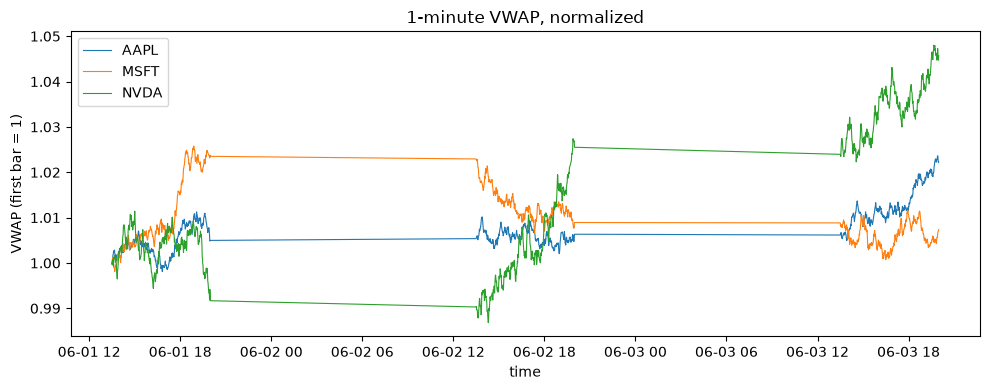

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
for sym, g in bars.groupby("symbol"):
    ax.plot(g["bar"], g["vwap"] / g["vwap"].iloc[0], label=sym, lw=0.8)
ax.set_title("1-minute VWAP, normalized")
ax.set_xlabel("time")
ax.set_ylabel("VWAP (first bar = 1)")
ax.legend()
fig.tight_layout()

## 4. Versions and time travel

`versions()` lists every commit the table has ever taken. Append a fourth day,
and the three-day table does not go anywhere: it is still readable as version
1. Opening an old version is O(1), because h5i-db reads an older manifest
rather than replaying anything.

In [8]:
day4 = cu.make_trades(symbols=["AAPL", "MSFT", "NVDA"], days=1, start="2026-06-04", seed=8)
db.append("trades", day4, note="day 4 feed")

[
    {k: v[k] for k in ("sequence", "op", "rows", "note") if k in v}
    for v in db.versions("trades")
]

[{'sequence': 0, 'op': 'create', 'rows': 0},
 {'sequence': 1, 'op': 'append', 'rows': 195277},
 {'sequence': 2, 'op': 'append', 'rows': 256223, 'note': 'day 4 feed'}]

In [9]:
v1_rows = len(db.read("trades", version=1))
v2_rows = len(db.read("trades", version=2))
latest = db.table("trades").select(count_star().alias("n")).to_pandas()["n"][0]
print(f"version 1: {v1_rows:,} rows\nversion 2: {v2_rows:,} rows\nlatest:    {latest:,} rows")

version 1: 195,277 rows
version 2: 256,223 rows
latest:    256,223 rows


Time travel also works inside a query, so an old version and the live table
can meet in one statement. Pass a read point to `db.table(...)` and it lowers
to the `h5i()` table function. Since the query is a Python value, write it once
as a function of the version and call it twice:

In [10]:
def per_symbol(version=None):
    return (
        db.table("trades", version=version)
        .group_by("symbol")
        .agg(count_star().alias("n"), col("ts").max().alias("mx"))
    )


was, now = per_symbol(1), per_symbol()
now.join(was, on="symbol").select(
    symbol=col("symbol", relation="l"),
    trades_added=col("n", relation="l") - col("n", relation="r"),
    ts_advanced_by=col("mx", relation="l") - col("mx", relation="r"),
).sort("symbol").to_pandas()

,symbol,trades_added,ts_advanced_by
0,AAPL,24438,1 days 00:00:00.157257
1,MSFT,14065,0 days 23:59:59.965784
2,NVDA,22443,0 days 23:59:59.829281


## Takeaways

- A database is a directory and a table is an Arrow schema plus a time column.
  No server, no daemon: `pip install`, `Database(path, create=True)`, done.
- `append` is an atomic commit with feed semantics, so batches must be
  strictly ordered in time. A bad ingest cannot damage what is already stored.
- OHLCV bars with VWAP are one aggregation, streaming over sorted storage.
  Build it with `db.table(...)` verbs or write it as SQL; `.sql()` is the door
  between the two (recipe 09).
- Time travel is first-class and O(1): `db.read(v)` in Python, `db.table(v)`
  in the builder, `h5i('table', v)` in SQL. It is the backbone of reproducible
  research, which recipe 05 picks up.

In [11]:
db.close()